In [2]:
#import thư viên+đọc dữ liệu
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MAIN_PATH = PROJECT_ROOT / "data" / "raw" / "khao_sat_AI_NLP_1000.csv"
UIT_PATH = PROJECT_ROOT / "data" / "raw" / "uit-vsfc" / "uit_vsfc_all.csv"

FIG_DIR = PROJECT_ROOT / "data" / "figures" / "eda"
RESULT_DIR = PROJECT_ROOT / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

df_main = pd.read_csv(MAIN_PATH)
df_uit = pd.read_csv(UIT_PATH)

print("Main:", df_main.shape)
print("UIT-VSFC:", df_uit.shape)

print("\nCột file khảo sát:")
print(df_main.columns.tolist())

print("\nCột UIT-VSFC:")
print(df_uit.columns.tolist())

df_main.head()

Main: (1000, 10)
UIT-VSFC: (16175, 6)

Cột file khảo sát:
['timestamp', 'linh_vuc', 'thoi_gian_dung_ai', 'thoi_gian_dung_ai_so', 'cong_cu_ai', 'so_cong_cu', 'nhan_xet', 'do_dai_nhan_xet', 'nhan', 'nhan_so']

Cột UIT-VSFC:
['text', 'label', 'label_id', 'topic', 'source', 'original_split']


,timestamp,linh_vuc,thoi_gian_dung_ai,thoi_gian_dung_ai_so,cong_cu_ai,so_cong_cu,nhan_xet,do_dai_nhan_xet,nhan,nhan_so
0,13/03/2026 10:58:05,Kinh tế,6-12 tháng,3,ChatGPT,1,Al này rất hiễu ích khi học và bài al giúp em ...,17,Tích cực,1
1,10/04/2026 02:27:37,Công nghệ thông tin,> 1 năm,4,ChatGPT,1,"Theo quan sát, Al rất hữu ích trong việc soạn ...",18,Bình thường,0
2,15/03/2026 05:09:43,Công nghệ thông tin,3-6 tháng,2,"ChatGPT, Gemini, Copilot, Midjourney",4,Khá thú vị khi Rất ổn để tôi viết nhiều mã tro...,19,Bình thường,0
3,05/04/2026 08:26:10,Kinh tế,3-6 tháng,2,"ChatGPT, Gemini",2,AI hỗ trợ em học tập hiệu quả hơn và tự học đư...,15,Tích cực,1
4,09/03/2026 04:37:51,Công nghệ thông tin,< 3 tháng,1,"ChatGPT, Gemini",2,AI hỗ trợ trong học tập và các lĩnh vực khác T...,13,Tích cực,1


In [3]:
#Chuẩn hóa 2 bộ dữ liệu về cùng format
df_main_std = df_main.rename(columns={
    "nhan_xet": "text",
    "nhan": "label",
    "nhan_so": "label_id"
}).copy()

df_main_std["source"] = "Khao_sat_AI"
df_main_std["original_split"] = "main"

df_main_std = df_main_std[["text", "label", "label_id", "source", "original_split"]]

df_uit_std = df_uit[["text", "label", "label_id", "source", "original_split"]].copy()

df_all = pd.concat([df_main_std, df_uit_std], ignore_index=True)

df_all["text"] = df_all["text"].astype(str).str.strip()
df_all["label"] = df_all["label"].astype(str).str.strip()

# Chuẩn hóa lại nhãn cho chắc chắn
label_map = {
    "negative": "Tiêu cực",
    "neutral": "Bình thường",
    "positive": "Tích cực",
    "tiêu cực": "Tiêu cực",
    "bình thường": "Bình thường",
    "trung lập": "Bình thường",
    "tích cực": "Tích cực",
    "0": "Tiêu cực",
    "1": "Bình thường",
    "2": "Tích cực"
}

df_all["label"] = df_all["label"].apply(
    lambda x: label_map.get(str(x).strip().lower(), x)
)

label_order = ["Tiêu cực", "Bình thường", "Tích cực"]

print("Tổng dữ liệu sau khi gộp:", df_all.shape)
print(df_all["label"].value_counts())

df_all.head()

Tổng dữ liệu sau khi gộp: (17175, 5)
label
Tích cực       8588
Tiêu cực       7509
Bình thường    1078
Name: count, dtype: int64


,text,label,label_id,source,original_split
0,Al này rất hiễu ích khi học và bài al giúp em ...,Tích cực,1,Khao_sat_AI,main
1,"Theo quan sát, Al rất hữu ích trong việc soạn ...",Bình thường,0,Khao_sat_AI,main
2,Khá thú vị khi Rất ổn để tôi viết nhiều mã tro...,Bình thường,0,Khao_sat_AI,main
3,AI hỗ trợ em học tập hiệu quả hơn và tự học đư...,Tích cực,1,Khao_sat_AI,main
4,AI hỗ trợ trong học tập và các lĩnh vực khác T...,Tích cực,1,Khao_sat_AI,main


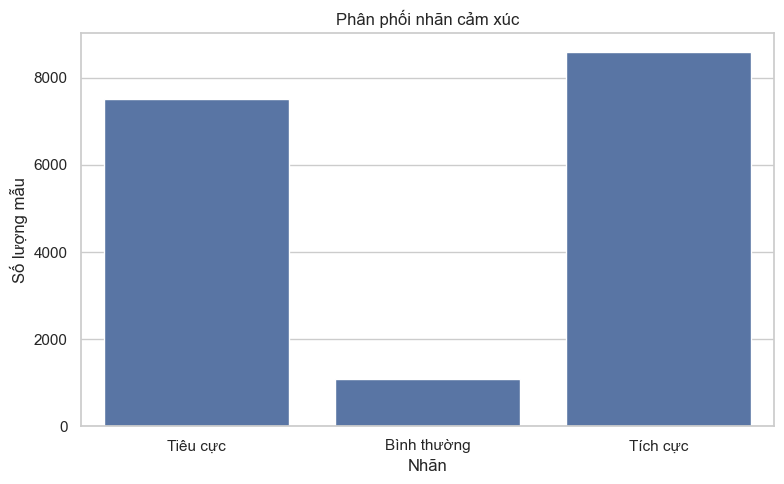

,count,percent
label,,
Tích cực,8588,50.00
Tiêu cực,7509,43.72
Bình thường,1078,6.28


In [4]:
#Biểu đồ 1: Phân phối nhãn
plt.figure(figsize=(8, 5))
sns.countplot(data=df_all, x="label", order=label_order)
plt.title("Phân phối nhãn cảm xúc")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng mẫu")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_label_distribution.png", dpi=300)
plt.show()

label_summary = pd.DataFrame({
    "count": df_all["label"].value_counts(),
    "percent": (df_all["label"].value_counts(normalize=True) * 100).round(2)
})

label_summary

**Nhận xét:** Dữ liệu sau khi gộp gồm bộ khảo sát chính và UIT-VSFC. Cần quan sát tỷ lệ từng nhãn để đánh giá mức độ mất cân bằng. Nếu nhãn Tiêu cực thấp hơn nhiều so với hai nhãn còn lại, nhóm cần dùng class-weight hoặc Focal Loss khi huấn luyện.

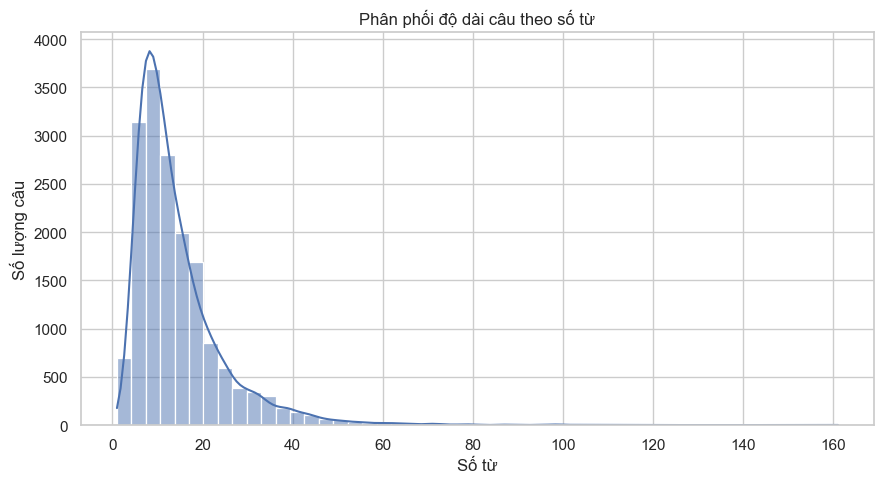

count    17175.000000
mean        14.428180
std         10.394644
min          1.000000
50%         11.000000
75%         18.000000
90%         26.600000
95%         34.000000
99%         52.000000
max        161.000000
Name: word_count, dtype: float64

In [5]:
#Biểu đồ 2: Phân phối độ dài câu
df_all["word_count"] = df_all["text"].str.split().str.len()

plt.figure(figsize=(9, 5))
sns.histplot(df_all["word_count"], bins=50, kde=True)
plt.title("Phân phối độ dài câu theo số từ")
plt.xlabel("Số từ")
plt.ylabel("Số lượng câu")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig02_text_length_distribution.png", dpi=300)
plt.show()

length_summary = df_all["word_count"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

length_summary

**Nhận xét:** Phần lớn câu có độ dài ngắn hoặc trung bình. Percentile 95 được dùng để đề xuất `max_length`, giúp giữ lại phần lớn dữ liệu nhưng tránh làm mô hình quá nặng.

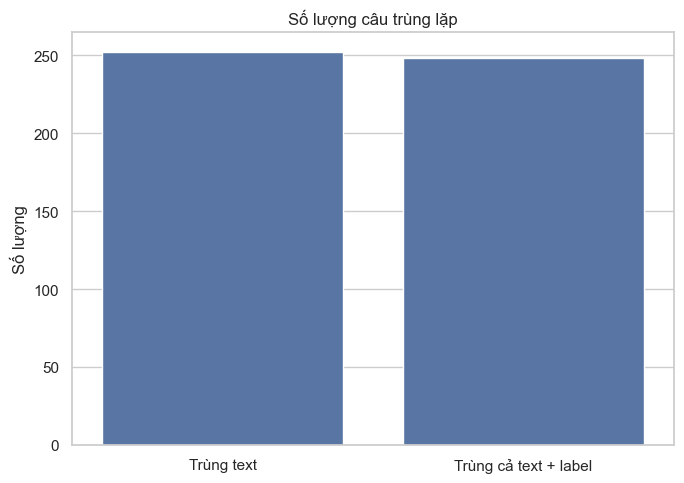

,Loại trùng,Số lượng
0,Trùng text,252
1,Trùng cả text + label,248


In [6]:
#Biểu đồ 3: Kiểm tra câu trùng lặp
duplicate_text_count = df_all.duplicated(subset=["text"]).sum()
duplicate_full_count = df_all.duplicated(subset=["text", "label"]).sum()

dup_df = pd.DataFrame({
    "Loại trùng": ["Trùng text", "Trùng cả text + label"],
    "Số lượng": [duplicate_text_count, duplicate_full_count]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=dup_df, x="Loại trùng", y="Số lượng")
plt.title("Số lượng câu trùng lặp")
plt.xlabel("")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_duplicate_counts.png", dpi=300)
plt.show()

dup_df

**Nhận xét:** Các câu trùng lặp cần được kiểm tra trước khi chia train/validation/test, vì nếu cùng một câu xuất hiện ở cả train và test thì kết quả đánh giá có thể bị cao giả tạo.

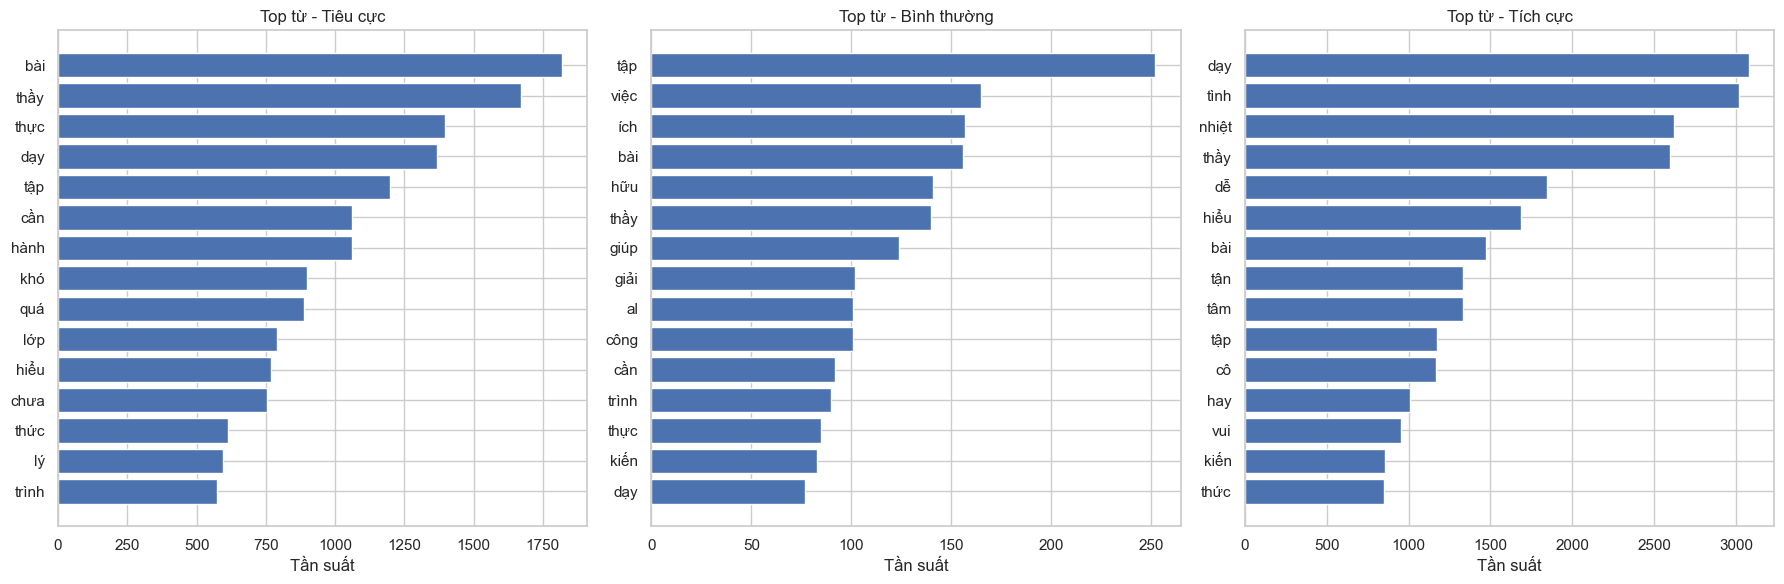

,label,word,count
0,Tiêu cực,bài,1819
1,Tiêu cực,thầy,1672
2,Tiêu cực,thực,1398
3,Tiêu cực,dạy,1369
4,Tiêu cực,tập,1199
5,Tiêu cực,cần,1061
6,Tiêu cực,hành,1060
7,Tiêu cực,khó,900
8,Tiêu cực,quá,886
9,Tiêu cực,lớp,790


In [7]:
#Biểu đồ 4: Top từ xuất hiện nhiều nhất theo nhãn
stopwords = {
    "và", "là", "của", "có", "cho", "trong", "với", "một", "các", "được",
    "này", "thì", "rất", "em", "tôi", "ai", "không", "để", "khi", "nên",
    "đã", "sẽ", "về", "ở", "ra", "nó", "cũng", "như", "làm", "bị",
    "hơn", "nhiều", "đến", "theo", "những", "còn", "nếu", "mình",
    "giảng", "viên", "sinh", "học", "môn"
}

def tokenize_simple(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ỹ0-9\s]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 1]
    return words

top_words_data = []

for label in label_order:
    texts = df_all.loc[df_all["label"] == label, "text"]
    words = []

    for t in texts:
        words.extend(tokenize_simple(t))

    common_words = Counter(words).most_common(15)

    for word, count in common_words:
        top_words_data.append({
            "label": label,
            "word": word,
            "count": count
        })

top_words_df = pd.DataFrame(top_words_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, label in zip(axes, label_order):
    temp = top_words_df[top_words_df["label"] == label].sort_values("count", ascending=True)
    ax.barh(temp["word"], temp["count"])
    ax.set_title(f"Top từ - {label}")
    ax.set_xlabel("Tần suất")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_top_words_by_label.png", dpi=300)
plt.show()

top_words_df

**Nhận xét:** Các từ xuất hiện nhiều theo từng nhãn giúp nhận diện đặc trưng cảm xúc và phát hiện nhiễu như tên công cụ, từ quá chung chung hoặc từ không mang nhiều ý nghĩa phân loại.

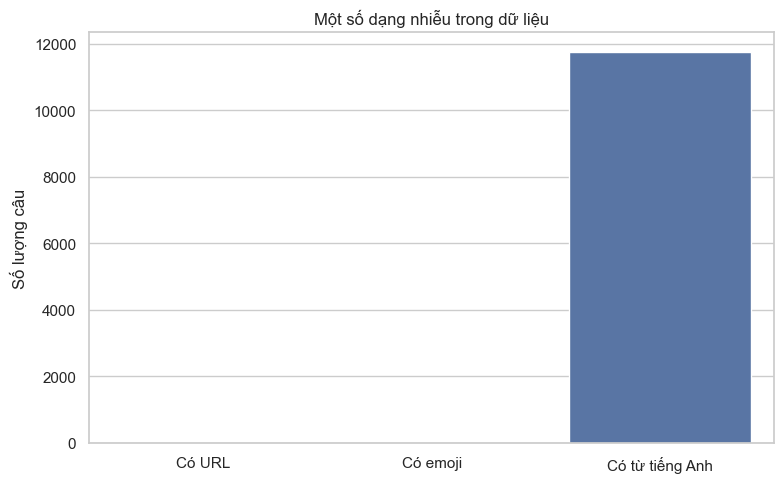

,Loại nhiễu,Số lượng
0,Có URL,0
1,Có emoji,2
2,Có từ tiếng Anh,11750


In [8]:
#Biểu đồ 5: Kiểm tra nhiễu URL, emoji, tiếng Anh
def has_url(text):
    return bool(re.search(r"http\S+|www\S+", str(text)))

def has_emoji(text):
    return bool(re.search(
        r"[\U0001F600-\U0001F64F"
        r"\U0001F300-\U0001F5FF"
        r"\U0001F680-\U0001F6FF"
        r"\U0001F1E0-\U0001F1FF]+",
        str(text)
    ))

def has_english_word(text):
    return bool(re.search(r"\b[a-zA-Z]{3,}\b", str(text)))

noise_stats = {
    "Có URL": int(df_all["text"].apply(has_url).sum()),
    "Có emoji": int(df_all["text"].apply(has_emoji).sum()),
    "Có từ tiếng Anh": int(df_all["text"].apply(has_english_word).sum()),
}

noise_df = pd.DataFrame({
    "Loại nhiễu": list(noise_stats.keys()),
    "Số lượng": list(noise_stats.values())
})

plt.figure(figsize=(8, 5))
sns.barplot(data=noise_df, x="Loại nhiễu", y="Số lượng")
plt.title("Một số dạng nhiễu trong dữ liệu")
plt.xlabel("")
plt.ylabel("Số lượng câu")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_noise_patterns.png", dpi=300)
plt.show()

noise_df

**Nhận xét:** Các câu chứa tiếng Anh, emoji hoặc URL cần được xử lý thống nhất trong bước tiền xử lý để tránh ảnh hưởng đến mô hình truyền thống như Naïve Bayes, SVM, BiLSTM và GRU.

In [9]:
#Tạo bảng tóm tắt EDA cuối notebook
summary = {
    "total_samples": len(df_all),
    "main_samples": len(df_main_std),
    "uit_vsfc_samples": len(df_uit_std),
    "negative_percent": round((df_all["label"] == "Tiêu cực").mean() * 100, 2),
    "neutral_percent": round((df_all["label"] == "Bình thường").mean() * 100, 2),
    "positive_percent": round((df_all["label"] == "Tích cực").mean() * 100, 2),
    "avg_word_count": round(df_all["word_count"].mean(), 2),
    "p95_word_count": round(df_all["word_count"].quantile(0.95), 2),
    "duplicate_text_count": int(duplicate_text_count),
    "duplicate_full_count": int(duplicate_full_count),
    "suggested_max_length": int(np.ceil(df_all["word_count"].quantile(0.95)))
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(RESULT_DIR / "eda_summary.csv", index=False, encoding="utf-8-sig")

summary_df

,total_samples,main_samples,uit_vsfc_samples,negative_percent,neutral_percent,positive_percent,avg_word_count,p95_word_count,duplicate_text_count,duplicate_full_count,suggested_max_length
0,17175,1000,16175,43.72,6.28,50.0,14.43,34.0,252,248,34


In [ ]:
negative_percent = round((df_all["label"] == "Tiêu cực").mean() * 100, 2)
neutral_percent = round((df_all["label"] == "Bình thường").mean() * 100, 2)
positive_percent = round((df_all["label"] == "Tích cực").mean() * 100, 2)

avg_len = round(df_all["word_count"].mean(), 2)
p95_len = round(df_all["word_count"].quantile(0.95), 2)
max_length = int(np.ceil(df_all["word_count"].quantile(0.95)))

if negative_percent < 15:
    risk_comment = "Nhãn Tiêu cực chiếm tỷ lệ thấp, cần xử lý mất cân bằng bằng class-weight hoặc Focal Loss."
elif max(negative_percent, neutral_percent, positive_percent) - min(negative_percent, neutral_percent, positive_percent) > 20:
    risk_comment = "Dữ liệu có dấu hiệu mất cân bằng nhãn, cần theo dõi khi huấn luyện mô hình."
else:
    risk_comment = "Phân phối nhãn tương đối ổn, chưa thấy rủi ro mất cân bằng quá nghiêm trọng."
print(df_all["source"].value_counts())
print(df_all["original_split"].value_counts())
print(f"Tổng số mẫu: {len(df_all)}")
print(
    f"Phân phối nhãn: "
    f"Tích cực {positive_percent}%  "
    f"Bình thường {neutral_percent}%  "
    f"Tiêu cực {negative_percent}%"
)
print(
    f"Độ dài trung bình: {avg_len} từ | "
    f"Percentile 95: {p95_len} từ → chọn max_length = {max_length}"
)
print(f"Số câu trùng: {duplicate_text_count}")
print(f"Nhận xét rủi ro chính: {risk_comment}")

Tổng số mẫu: 17175
Phân phối nhãn: Tích cực 50.0%  Bình thường 6.28%  Tiêu cực 43.72%
Độ dài trung bình: 14.43 từ | Percentile 95: 34.0 từ → chọn max_length = 34
Số câu trùng: 252
Nhận xét rủi ro chính: Dữ liệu có dấu hiệu mất cân bằng nhãn, cần theo dõi khi huấn luyện mô hình.


In [11]:
#Kiểm tra file output đã tạo
print("Các biểu đồ đã lưu:")

for path in sorted(FIG_DIR.glob("*.png")):
    print("-", path.relative_to(PROJECT_ROOT))

print("\nBảng tóm tắt:")
summary_path = RESULT_DIR / "eda_summary.csv"
print(summary_path.relative_to(PROJECT_ROOT), "exists =", summary_path.exists())

Các biểu đồ đã lưu:
- data\figures\eda\fig01_label_distribution.png
- data\figures\eda\fig02_text_length_distribution.png
- data\figures\eda\fig03_duplicate_counts.png
- data\figures\eda\fig04_top_words_by_label.png
- data\figures\eda\fig05_noise_patterns.png

Bảng tóm tắt:
results\eda_summary.csv exists = True
